# 1 Inequality in Denmark

In [1]:
# Imprts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Indlæser og sortere data
url41 = "https://api.statbank.dk/v1/data/IFOR41/CSV?ULLIG=70&KOMMUNEDK=*&Tid=*"
gini_raw = pd.read_csv(url41, sep=";")

gini_raw = gini_raw[["KOMMUNEDK", "TID", "INDHOLD"]].copy()
gini_raw.columns = ["municipality", "Year", "Gini"]

gini_raw["municipality"] = gini_raw["municipality"].astype(str)
gini_raw["Year"] = pd.to_numeric(gini_raw["Year"], errors="coerce")
gini_raw["Gini"] = pd.to_numeric(
    gini_raw["Gini"].astype(str).str.replace(",", "."),
    errors="coerce"
)
gini_raw = gini_raw.dropna().sort_values(["municipality", "Year"]).reset_index(drop=True)

url32 = "https://api.statbank.dk/v1/data/IFOR32/CSV?DECILGEN=*&KOMMUNEDK=*&Tid=*"
decile_raw = pd.read_csv(url32, sep=";")

decile_raw = decile_raw[["KOMMUNEDK", "DECILGEN", "TID", "INDHOLD"]].copy()
decile_raw.columns = ["municipality", "decile", "Year", "income"]

decile_raw["municipality"] = decile_raw["municipality"].astype(str)
decile_raw["Year"] = pd.to_numeric(decile_raw["Year"], errors="coerce")
decile_raw["income"] = pd.to_numeric(
    decile_raw["income"].astype(str).str.replace(",", "."),
    errors="coerce"
)
decile_raw["decile"] = decile_raw["decile"].astype(str).str.extract(r"(\d+)")
decile_raw["decile"] = pd.to_numeric(decile_raw["decile"], errors="coerce")
decile_raw = decile_raw.dropna().sort_values(["municipality", "Year", "decile"]).reset_index(drop=True)


### 1.1 The Gini coefficient and the top 10 percent share

We use IFOR41 to plot the Gini coefficient for Denmark over time. The figure shows how overall inequality changes over the period, and it indicates that inequality has fluctuated over time but has a upward trend.

We use IFOR32 to compute the share of total income going to the richest 10 percent. Because each decile contains the same number of individuals, the top 10 percent share is

$$
\text{top 10\% share} = \frac{\bar{y}_{10}}{\sum_{d=1}^{10} \bar{y}_d}
$$

The second figure shows that the Gini coefficient and the top 10 percent share move together over time. This tells us that both measures capture the same broad development: when inequality rises, the income share of the top decile also rises. The correlation between the two series is positive and relatively high, so the two measures describe the same overall pattern, although the Gini coefficient is a broader measure and the top 10 percent share focuses more directly on the upper tail.

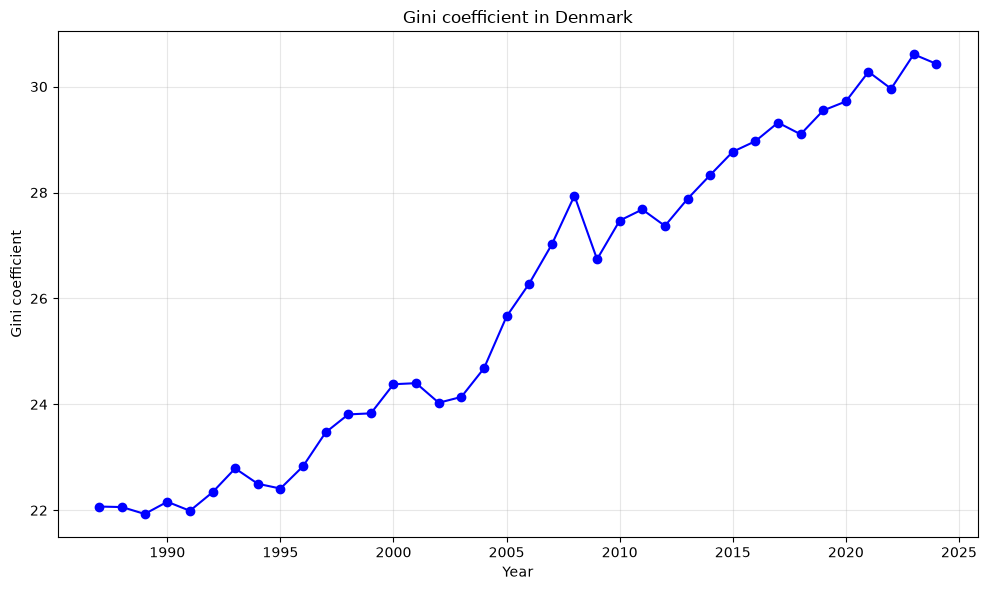

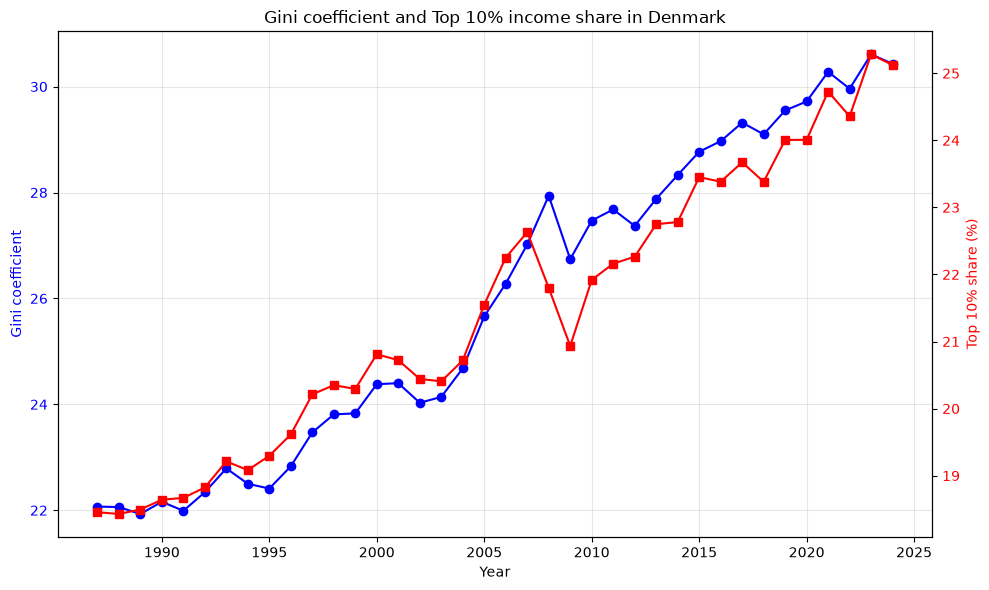

Correlation: 0.982


In [2]:
# National data: keep only "Hele landet"
gini_nat = gini_raw[
    gini_raw["municipality"].str.contains("Hele landet", case=False, na=False)
].copy().sort_values("Year").reset_index(drop=True)

decile_nat = decile_raw[
    decile_raw["municipality"].str.contains("Hele landet", case=False, na=False)
].copy().sort_values(["Year", "decile"]).reset_index(drop=True)

decile_pivot = decile_nat.pivot_table(
    index="Year",
    columns="decile",
    values="income",
    aggfunc="first"
).sort_index()

decile_pivot = decile_pivot.reindex(columns=range(1, 11), fill_value=np.nan)
top10_share = decile_pivot[10] / decile_pivot.sum(axis=1)

top10 = top10_share.reset_index()
top10.columns = ["Year", "Top10Share"]

merged = gini_nat.merge(top10, on="Year", how="inner")

# Figure 1: Gini coefficient over time
plt.figure(figsize=(10, 6))
plt.plot(merged["Year"], merged["Gini"], color="blue", marker="o")
plt.title("Gini coefficient in Denmark")
plt.xlabel("Year")
plt.ylabel("Gini coefficient")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 2: Gini and top 10% share in the same figure
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(merged["Year"], merged["Gini"], color="blue", marker="o", label="Gini coefficient")
ax1.set_xlabel("Year")
ax1.set_ylabel("Gini coefficient", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(merged["Year"], merged["Top10Share"] * 100, color="red", marker="s", label="Top 10% share")
ax2.set_ylabel("Top 10% share (%)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Gini coefficient and Top 10% income share in Denmark")
fig.tight_layout()
plt.show()

corr = merged["Gini"].corr(merged["Top10Share"])
print(f"Correlation: {corr:.3f}")

### 1.2 Prediction

We fit a linear and a quadratic trend to the Gini coefficient by least squares, using the time index since 1987. The linear model gives a straight-line trend, while the quadratic model allows for curvature. We then use both models to predict the Gini coefficient in 2030 and 2040 and compare the fitted values with the historical data.

The two models give similar short-run predictions, but they differ more in the long run because the historical series is not perfectly linear. The quadratic model usually fits the data better if the trend bends over time, but neither model should be treated as a strong forecast of future inequality, since it does not include the institutional and economic changes that may affect inequality.

Linear coefficients:
beta0 = 21.0428
beta1 = 0.2635
Quadratic coefficients:
beta0 = 21.3042
beta1 = 0.2200
beta2 = 0.001178
Linear coefficients: 0.264, 21.043
Quadratic coefficients: 0.001, 0.220, 21.304
Year 2030: linear = 32.375, quadratic = 32.941
Year 2040: linear = 35.011, quadratic = 36.271


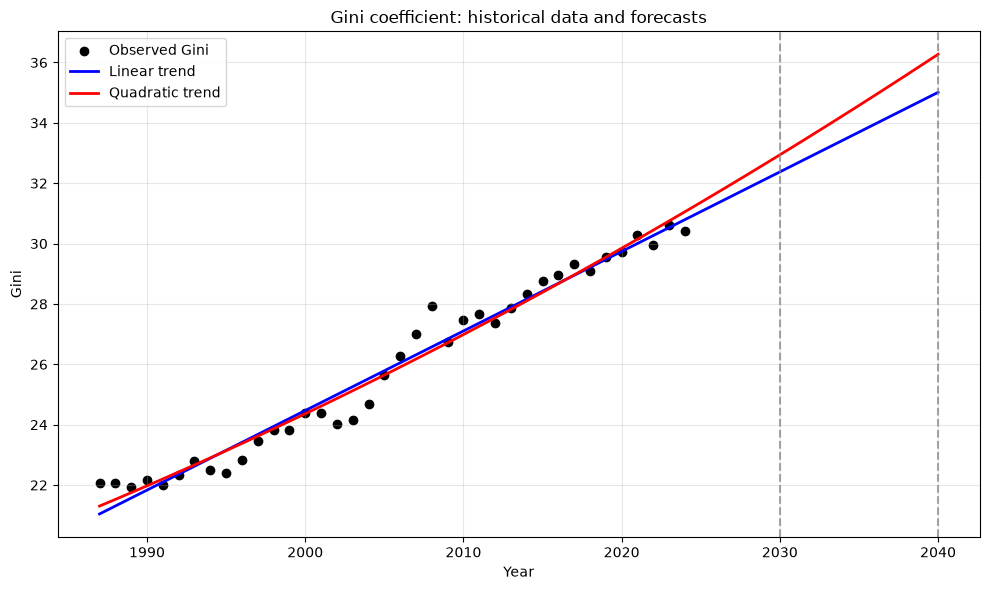

In [3]:
# Minimize SSE with scipy.optimize.minimize
gini_fit = gini_nat.copy()
gini_fit["t"] = gini_fit["Year"] - gini_fit["Year"].min()

t = gini_fit["t"].to_numpy()
y = gini_fit["Gini"].to_numpy()

# Linear trend
def sse_linear(beta, t, y):
    y_hat = beta[0] + beta[1] * t
    return np.sum((y - y_hat) ** 2)

result_linear = minimize(
    sse_linear,
    x0=[20, 0.1],
    args=(t, y)
)

beta_linear = result_linear.x
print("Linear coefficients:")
print(f"beta0 = {beta_linear[0]:.4f}")
print(f"beta1 = {beta_linear[1]:.4f}")

# Quadratic trend
def sse_quadratic(beta, t, y):
    y_hat = beta[0] + beta[1] * t + beta[2] * t**2
    return np.sum((y - y_hat) ** 2)

result_quadratic = minimize(
    sse_quadratic,
    x0=[20, 0.1, 0.001],
    args=(t, y)
)

beta_quadratic = result_quadratic.x
print("Quadratic coefficients:")
print(f"beta0 = {beta_quadratic[0]:.4f}")
print(f"beta1 = {beta_quadratic[1]:.4f}")
print(f"beta2 = {beta_quadratic[2]:.6f}")

# Minimize with polyfit
coef_lin = np.polyfit(t, y, 1)
coef_quad = np.polyfit(t, y, 2)

print(f"Linear coefficients: {coef_lin[0]:.3f}, {coef_lin[1]:.3f}")
print(f"Quadratic coefficients: {coef_quad[0]:.3f}, {coef_quad[1]:.3f}, {coef_quad[2]:.3f}")

# Forecasts for 2030 and 2040 with a for loop
for year in [2030, 2040]:
    tau = year - gini_fit["Year"].min()
    lin_pred = beta_linear[0] + beta_linear[1] * tau
    quad_pred = beta_quadratic[0] + beta_quadratic[1] * tau + beta_quadratic[2] * tau**2
    print(f"Year {year}: linear = {lin_pred:.3f}, quadratic = {quad_pred:.3f}")

# Plot observed data + fitted trends
years_future = np.arange(gini_fit["Year"].min(), 2041)
t_future = years_future - gini_fit["Year"].min()

linear_fit = beta_linear[0] + beta_linear[1] * t_future
quadratic_fit = beta_quadratic[0] + beta_quadratic[1] * t_future + beta_quadratic[2] * t_future**2

plt.figure(figsize=(10, 6))
plt.scatter(gini_fit["Year"], gini_fit["Gini"], color="black", label="Observed Gini")
plt.plot(years_future, linear_fit, color="blue", linewidth=2, label="Linear trend")
plt.plot(years_future, quadratic_fit, color="red", linewidth=2, label="Quadratic trend")
plt.axvline(2030, color="gray", linestyle="--", alpha=0.7)
plt.axvline(2040, color="gray", linestyle="--", alpha=0.7)
plt.title("Gini coefficient: historical data and forecasts")
plt.xlabel("Year")
plt.ylabel("Gini")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.3 Municipalities

At the municipality level, we compute the correlation between the Gini coefficient and the top 10 percent share in the most recent year. This tells us whether municipalities with high overall inequality also have a large concentration of income at the top.

We then identify the 10 most unequal and the 10 least unequal municipalities and show them in a figure. The figure shows which municipalities are most and least unequal in the latest year. We also look at the municipalities with the largest and smallest change in the Gini coefficient over time, but we only interpret these rankings after checking the underlying time series, because a small population can make the Gini coefficient very sensitive to a single large income observation.

Correlation across municipalities in 2024: 0.975
Most unequal:
      municipality   Gini
24        Gentofte  49.04
73       Rudersdal  47.31
92           Vejen  46.32
43        Hørsholm  40.07
56  Lyngby-Taarbæk  39.28
20   Frederiksberg  36.54
50       København  34.97
2           Aarhus  33.43
18     Fredensborg  32.76
33       Helsingør  30.55

Most equal:
       municipality   Gini
14  Faaborg-Midtfyn  23.77
12           Egedal  23.85
8          Bornholm  24.03
17             Faxe  24.09
16         Favrskov  24.41
31          Halsnæs  24.41
5            Assens  24.46
32        Hedensted  24.58
3       Albertslund  24.66
65            Odder  24.70


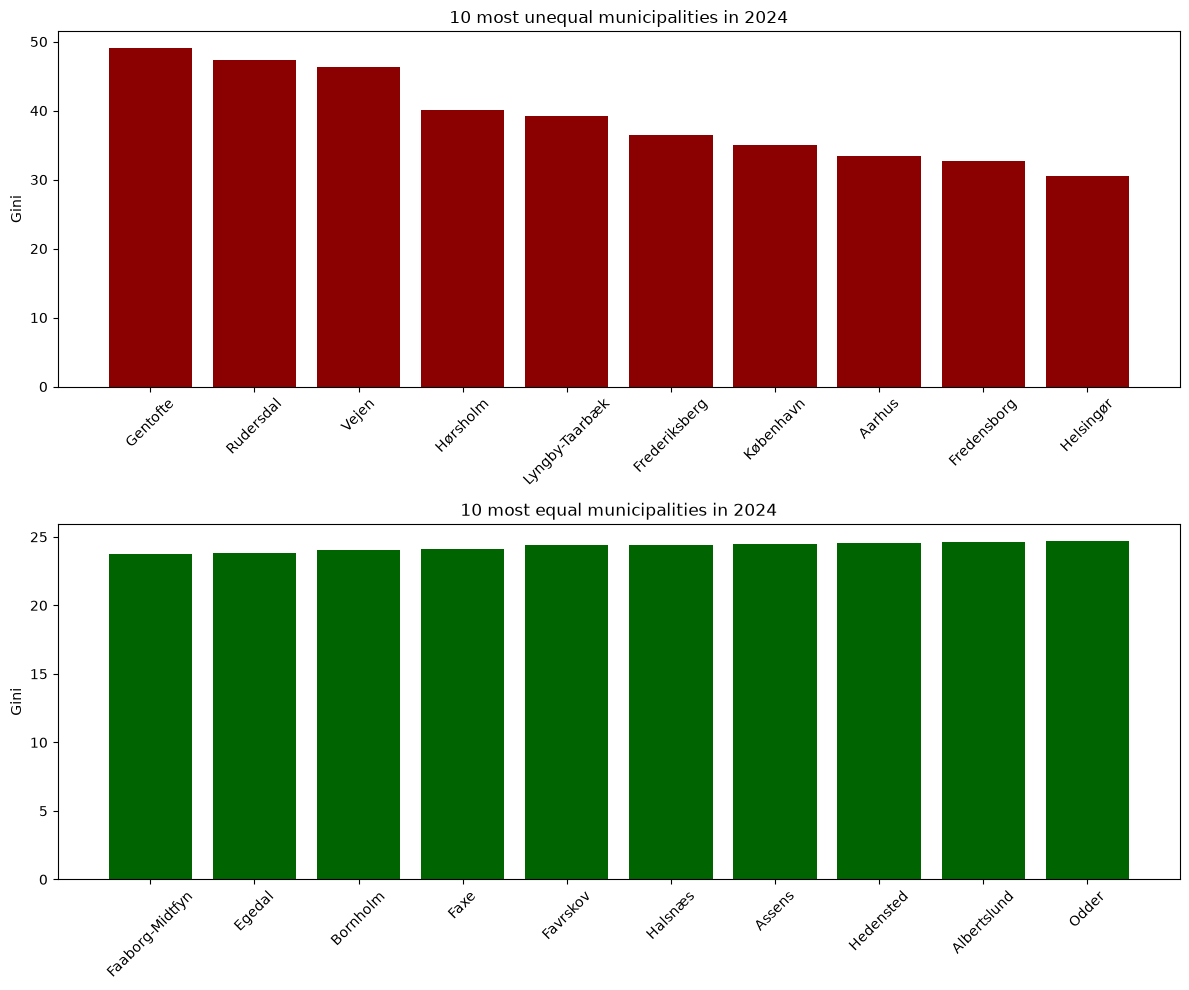


Largest increase in Gini:
      municipality  gini_first  gini_last  change
92           Vejen       21.20      46.32   25.12
73       Rudersdal       29.05      47.31   18.26
24        Gentofte       31.10      49.04   17.94
56  Lyngby-Taarbæk       24.97      39.28   14.31
50       København       23.05      34.97   11.92
43        Hørsholm       28.39      40.07   11.68
18     Fredensborg       21.17      32.76   11.59
2           Aarhus       22.10      33.43   11.33
20   Frederiksberg       25.28      36.54   11.26
90      Vallensbæk       15.90      26.70   10.80

Smallest change in Gini:
       municipality  gini_first  gini_last  change
15             Fanø       25.67      26.34    0.67
97              Ærø       24.63      26.98    2.35
17             Faxe       21.64      24.09    2.45
57             Læsø       22.81      25.41    2.60
8          Bornholm       21.31      24.03    2.72
14  Faaborg-Midtfyn       20.88      23.77    2.89
81             Sorø       22.24      25.

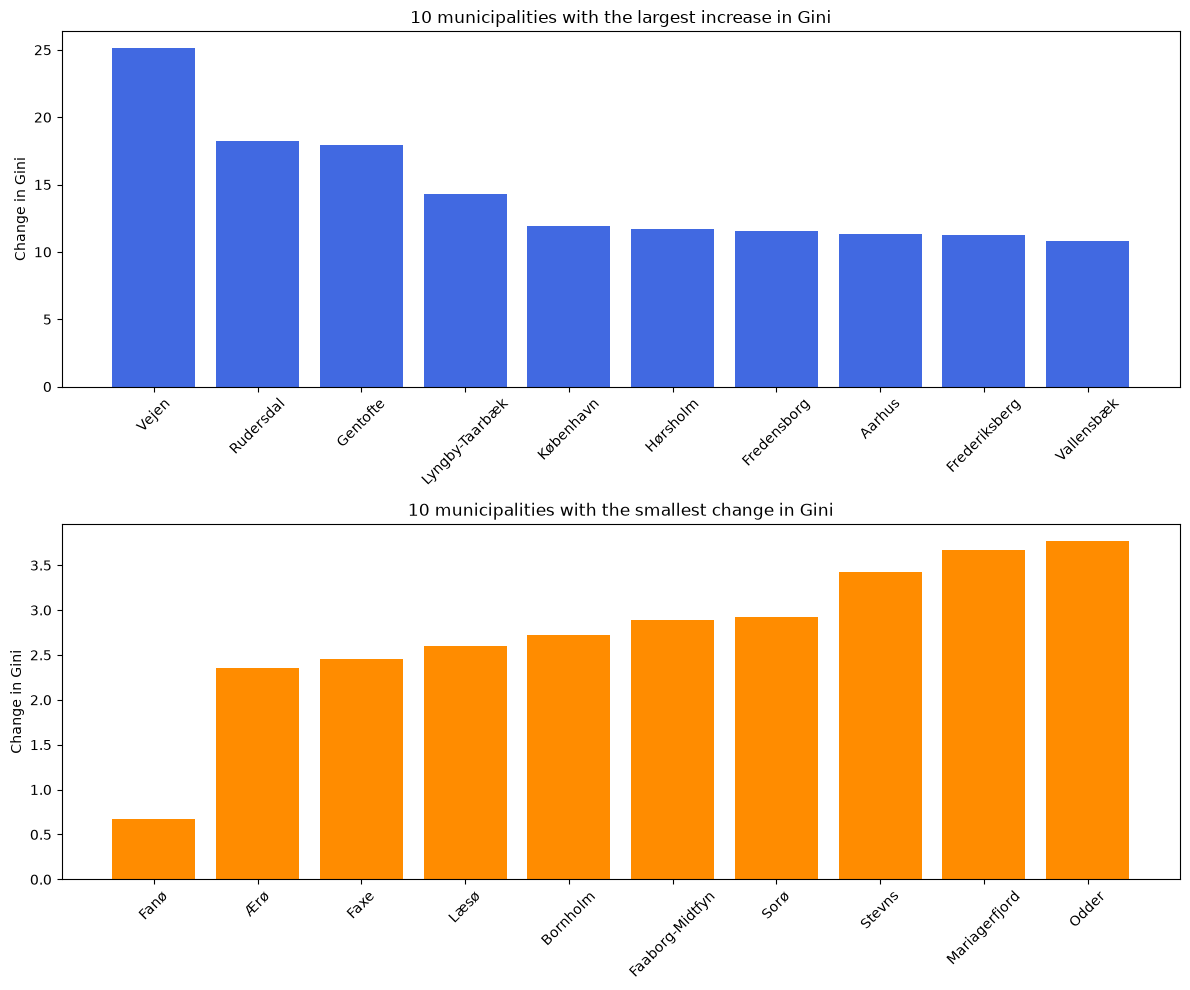

In [4]:
# Reuse the already cleaned raw data and filter out the national aggregate
gini = gini_raw[
    ~gini_raw["municipality"].str.contains("Hele landet", case=False, na=False)
].copy().sort_values(["municipality", "Year"]).reset_index(drop=True)

decile = decile_raw[
    ~decile_raw["municipality"].str.contains("Hele landet", case=False, na=False)
].copy().sort_values(["municipality", "Year", "decile"]).reset_index(drop=True)

# 2) Top 10% share
decile_pivot = decile.pivot_table(
    index=["municipality", "Year"],
    columns="decile",
    values="income",
    aggfunc="first"
).reindex(columns=range(1, 11), fill_value=np.nan)

top10_share = decile_pivot[10] / decile_pivot.sum(axis=1)
top10 = top10_share.reset_index()
top10.columns = ["municipality", "Year", "Top10Share"]

# 3) Latest year and correlation across municipalities
latest_year = max(gini["Year"].max(), top10["Year"].max())
gini_latest = gini[gini["Year"] == latest_year].copy()
top10_latest = top10[top10["Year"] == latest_year].copy()

df = gini_latest.merge(top10_latest, on=["municipality", "Year"], how="inner")

corr = df["Gini"].corr(df["Top10Share"])
print(f"Correlation across municipalities in {latest_year}: {corr:.3f}")

# 4) Most unequal / most equal municipalities in the most recent year
most_unequal = df.sort_values("Gini", ascending=False).head(10).copy()
most_equal = df.sort_values("Gini", ascending=True).head(10).copy()

print("Most unequal:")
print(most_unequal[["municipality", "Gini"]])

print("\nMost equal:")
print(most_equal[["municipality", "Gini"]])

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].bar(most_unequal["municipality"], most_unequal["Gini"], color="darkred")
axes[0].set_title(f"10 most unequal municipalities in {latest_year}")
axes[0].set_ylabel("Gini")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(most_equal["municipality"], most_equal["Gini"], color="darkgreen")
axes[1].set_title(f"10 most equal municipalities in {latest_year}")
axes[1].set_ylabel("Gini")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 5) Largest and smallest change in Gini over time
gini_change = (
    gini.groupby("municipality")
    .agg(gini_first=("Gini", "first"), gini_last=("Gini", "last"))
    .reset_index()
)
gini_change["change"] = gini_change["gini_last"] - gini_change["gini_first"]

largest_change = gini_change.sort_values("change", ascending=False).head(10)
smallest_change = gini_change.sort_values("change", ascending=True).head(10)

print("\nLargest increase in Gini:")
print(largest_change[["municipality", "gini_first", "gini_last", "change"]])

print("\nSmallest change in Gini:")
print(smallest_change[["municipality", "gini_first", "gini_last", "change"]])

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].bar(largest_change["municipality"], largest_change["change"], color="royalblue")
axes[0].set_title("10 municipalities with the largest increase in Gini")
axes[0].set_ylabel("Change in Gini")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(smallest_change["municipality"], smallest_change["change"], color="darkorange")
axes[1].set_title("10 municipalities with the smallest change in Gini")
axes[1].set_ylabel("Change in Gini")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 1.4 Extension

As an extension, we add another municipality-level variable and relate it to the Gini coefficient or to its change over time. The purpose is to see whether inequality is associated with other local characteristics, such as unemployment, education, or other demographic and economic differences across municipalities.

the municipality-level correlation is very strong and positive, which matches the national pattern over time. The unequal municipalities are mainly wealthy suburban municipalities, while the more equal ones tend to be smaller or less affluent municipalities. The largest changes mostly reflect municipal changes over time rather than one-off extreme incomes, so the time-series plots are important for checking whether a ranking is driven by a single unusually large income year.

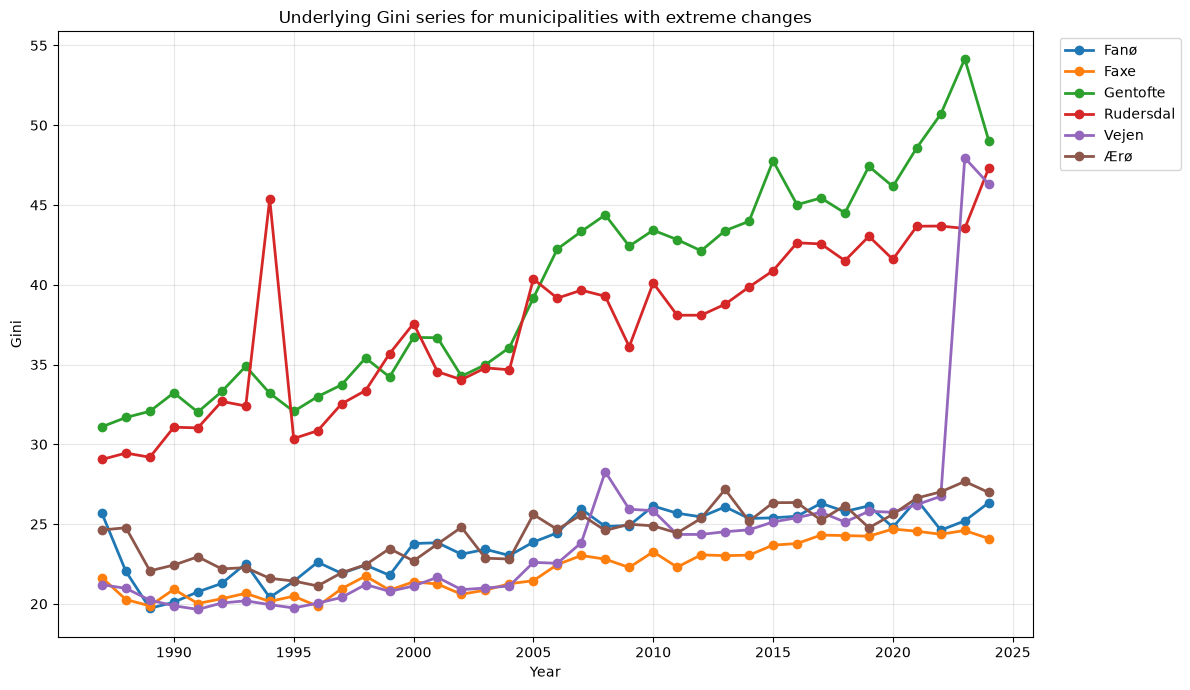


Interpretation: the municipality-level correlation is very strong and positive,
which matches the national pattern over time. The unequal municipalities are mainly
wealthy suburban municipalities, while the more equal ones tend to be smaller or
less affluent municipalities. The largest changes mostly reflect municipal changes
over time rather than one-off extreme incomes, so the time-series plots are important
for checking whether a ranking is driven by a single unusually large income year.


In [ ]:
# Also inspect the underlying series for the municipalities with the largest/smallest changes
selected_change_municipalities = list(largest_change["municipality"].head(3)) + list(smallest_change["municipality"].head(3))
change_series_selected = gini[gini["municipality"].isin(selected_change_municipalities)].copy()

fig, ax = plt.subplots(figsize=(12, 7))
for muni, grp in change_series_selected.groupby("municipality"):
    ax.plot(grp["Year"], grp["Gini"], marker="o", linewidth=2, label=muni)
ax.set_title("Underlying Gini series for municipalities with extreme changes")
ax.set_xlabel("Year")
ax.set_ylabel("Gini")
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()